In [1]:
import duckdb
import pandas as pd
from pathlib import Path
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from pmdarima import auto_arima

In [2]:
db_path = Path(f'{Path.cwd()}/sm_db.duckdb')
print(f"cwd: {Path.cwd()} \n filepaht: {db_path}")
db_path.exists()
conn = duckdb.connect(db_path, read_only=True)
stroke_mortality_clean = conn.sql("SELECT  * FROM stroke_mortality;").df()


cwd: c:\Data_Analysis_Projects\HHS_data_analysis\analysis\stroke_mortality_analysis 
 filepaht: c:\Data_Analysis_Projects\HHS_data_analysis\analysis\stroke_mortality_analysis\sm_db.duckdb


In [3]:
stroke_mortality_clean.head()

,id,api_id,year,state,location,geo_level,rate,sex,race,fips,icd_class,value,topic
0,1490899,row-9mxu_6uqv-j4kv,2004,IL,Schuyler,County,"per 100,000",Women,Overall,17169,Cardiovascular Diseases,41.0,Coronary heart disease (CHD)
1,1490900,row-rgch~giks_tdv8,2017,IL,Schuyler,County,"per 100,000",Women,Overall,17169,Cardiovascular Diseases,39.4,Coronary heart disease (CHD)
2,1490901,row-asyv_kbrc-barf,1999,IL,Schuyler,County,"per 100,000",Women,Overall,17169,Cardiovascular Diseases,52.6,Coronary heart disease (CHD)
3,1490902,row-6scm_2i8j.jaqv,2019,IL,Schuyler,County,"per 100,000",Women,Overall,17169,Cardiovascular Diseases,38.0,Coronary heart disease (CHD)
4,1490903,row-dx4n~f74v_k85s,2018,IL,Schuyler,County,"per 100,000",Women,Overall,17169,Cardiovascular Diseases,40.7,Coronary heart disease (CHD)


In [4]:
stroke_mortality_clean['sex'] = stroke_mortality_clean['sex'].replace('Men', 'Male')
stroke_mortality_clean['sex'] = stroke_mortality_clean['sex'].replace('Women', 'Female')
stroke_mortality_clean['race'] = stroke_mortality_clean['race'].replace('American Indian or Alaska Native', 'American Indian/Alaska Native')
stroke_mortality_clean['race'] = stroke_mortality_clean['race'].replace('Black', 'Black (Non-Hispanic)')
stroke_mortality_clean['race'] = stroke_mortality_clean['race'].replace('Asian', 'Asian/Pacific Islander')
stroke_mortality_clean['race'] = stroke_mortality_clean['race'].replace('Native Hawaiian or Other Pacific Islander', 'Asian/Pacific Islander')


In [5]:
stroke_mortality_clean['race'].unique()

<StringArray>
[                      'Overall',                         'White',
          'Black (Non-Hispanic)',                      'Hispanic',
        'Asian/Pacific Islander', 'American Indian/Alaska Native',
            'More than one race']
Length: 7, dtype: str

In [6]:
stroke_mortality_clean['sex'].unique()

<StringArray>
['Female', 'Overall', 'Male']
Length: 3, dtype: str

In [7]:
stroke_mortality_clean['location'] = stroke_mortality_clean['location'].str.replace('County', '' ,regex=False).str.strip()

In [8]:
stroke_mortality_clean['location'].unique()

<StringArray>
[     'Schuyler',        'Shelby',         'Piatt',     'Vermilion',
     'Anchorage',         'White',          'Pike',      'Randolph',
        'Wabash',         'Iosco',
 ...
 'West Virginia',    'Sweetwater',         'Uinta',      'Washakie',
        'Weston',   'Puerto Rico',       'Newport',    'Providence',
  'Rhode Island',  'South Dakota']
Length: 2061, dtype: str

In [9]:
stroke_mortality_clean.count()


id           5417584
api_id       5417584
year         5417584
state        5417584
location     5417584
geo_level    5417584
rate         5417584
sex          5417584
race         5417584
fips         5417584
icd_class    5417584
value        3162919
topic        5407824
dtype: int64

In [10]:
stroke_mortality_clean = stroke_mortality_clean.dropna()

In [11]:
stroke_mortality_clean.count()

id           3157962
api_id       3157962
year         3157962
state        3157962
location     3157962
geo_level    3157962
rate         3157962
sex          3157962
race         3157962
fips         3157962
icd_class    3157962
value        3157962
topic        3157962
dtype: int64

In [12]:
stroke_mortality_clean.head()

,id,api_id,year,state,location,geo_level,rate,sex,race,fips,icd_class,value,topic
0,1490899,row-9mxu_6uqv-j4kv,2004,IL,Schuyler,County,"per 100,000",Female,Overall,17169,Cardiovascular Diseases,41.0,Coronary heart disease (CHD)
1,1490900,row-rgch~giks_tdv8,2017,IL,Schuyler,County,"per 100,000",Female,Overall,17169,Cardiovascular Diseases,39.4,Coronary heart disease (CHD)
2,1490901,row-asyv_kbrc-barf,1999,IL,Schuyler,County,"per 100,000",Female,Overall,17169,Cardiovascular Diseases,52.6,Coronary heart disease (CHD)
3,1490902,row-6scm_2i8j.jaqv,2019,IL,Schuyler,County,"per 100,000",Female,Overall,17169,Cardiovascular Diseases,38.0,Coronary heart disease (CHD)
4,1490903,row-dx4n~f74v_k85s,2018,IL,Schuyler,County,"per 100,000",Female,Overall,17169,Cardiovascular Diseases,40.7,Coronary heart disease (CHD)


In [13]:
stroke_mortality_clean.count()

id           3157962
api_id       3157962
year         3157962
state        3157962
location     3157962
geo_level    3157962
rate         3157962
sex          3157962
race         3157962
fips         3157962
icd_class    3157962
value        3157962
topic        3157962
dtype: int64

In [26]:
Nj_Stroke_Mortality = stroke_mortality_clean[
    (stroke_mortality_clean['sex'] == 'Overall') &
    (stroke_mortality_clean['race'] == 'Overall') &
    (stroke_mortality_clean['state'] == 'NJ') &
    (stroke_mortality_clean['topic'].isin(['All stroke', 'Stroke Mortality']))
].copy()

In [27]:
Nj_Stroke_Mortality = Nj_Stroke_Mortality.sort_values('year')
Nj_Stroke_Mortality['year'] = pd.to_datetime(Nj_Stroke_Mortality['year'],format='%Y')
Nj_Stroke_Mortality = Nj_Stroke_Mortality[(Nj_Stroke_Mortality['geo_level'] == 'County')]

In [28]:
Nj_Stroke_Mortality

,id,api_id,year,state,location,geo_level,rate,sex,race,fips,icd_class,value,topic
1606551,3347094,row-a7td_b8gk.fv3g,1999-01-01,NJ,Cape May,County,"per 100,000",Overall,Overall,34009,Cardiovascular Diseases,14.8,All stroke
1612290,3366356,row-3jeb_5bui-45ay,1999-01-01,NJ,Mercer,County,"per 100,000",Overall,Overall,34021,Cardiovascular Diseases,16.4,All stroke
1598487,3338689,row-z4ss~pzhz.ts5z,1999-01-01,NJ,Bergen,County,"per 100,000",Overall,Overall,34003,Cardiovascular Diseases,337.1,All stroke
1596803,3335321,row-yk4c_q8ww-xpga,1999-01-01,NJ,Atlantic,County,"per 100,000",Overall,Overall,34001,Cardiovascular Diseases,366.6,All stroke
1636787,3362754,row-ex9x.5i8e_k2ym,1999-01-01,NJ,Warren,County,"per 100,000",Overall,Overall,34041,Cardiovascular Diseases,11.0,All stroke
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3075404,333107,row-vcfa~n62d~wbem,2023-01-01,NJ,Burlington,County,"per 100,000 population",Overall,Overall,34005,Cardiovascular Diseases,68.7,Stroke Mortality
3075403,333106,row-qxba.z3gs_usk4,2023-01-01,NJ,Bergen,County,"per 100,000 population",Overall,Overall,34003,Cardiovascular Diseases,45.1,Stroke Mortality
3075402,333105,row-67fa_65wd-d8ns,2023-01-01,NJ,Atlantic,County,"per 100,000 population",Overall,Overall,34001,Cardiovascular Diseases,55.5,Stroke Mortality
3075422,333125,row-xvtq~a4ad~gu4m,2023-01-01,NJ,Warren,County,"per 100,000 population",Overall,Overall,34041,Cardiovascular Diseases,54.5,Stroke Mortality


In [29]:
Nj_Stroke_Mortality.count()

id           924
api_id       924
year         924
state        924
location     924
geo_level    924
rate         924
sex          924
race         924
fips         924
icd_class    924
value        924
topic        924
dtype: int64

In [31]:
county_year = (Nj_Stroke_Mortality.groupby(['year', 'location'])['value'].mean().rename('county_rate'))
nj_state = (county_year.groupby('year').mean().rename('stroke_rate'))
nj_state.index = pd.to_datetime(nj_state.index, format='%Y')
nj_state

year
1999-01-01    181.857143
2000-01-01    187.959524
2001-01-01    176.040476
2002-01-01    173.078571
2003-01-01    167.678571
2004-01-01    157.459524
2005-01-01    149.823810
2006-01-01    140.135714
2007-01-01    137.721429
2008-01-01    127.442857
2009-01-01    125.790476
2010-01-01    125.023810
2011-01-01    127.145238
2012-01-01    124.435714
2013-01-01    122.650000
2014-01-01    120.550000
2015-01-01    120.850000
2016-01-01    118.904762
2017-01-01    117.809524
2018-01-01    115.733333
2019-01-01    115.097619
2020-01-01     63.580952
2023-01-01     57.876190
Name: stroke_rate, dtype: float64

In [ ]:
# nj_state.count()

In [ ]:
county_year.count()


np.int64(1197)

In [ ]:
county_year

year        location 
1999-01-01  Alameda      270.40
            Amador       266.90
            Butte        264.65
            Calaveras    214.90
            Colusa       204.50
                          ...  
2019-01-01  Tulare       156.55
            Tuolumne     129.75
            Ventura      137.65
            Yolo         133.60
            Yuba         166.80
Name: county_rate, Length: 1197, dtype: float64

In [ ]:
def adf_report(series, name):
    r = adfuller(series.dropna(), autolag='AIC')
    stationary = "STATIONARY" if r[1] < 0.05 else "NON-STATIONARY"
    print(f"{name:12s} ADF = {r[0]:7.3f}   p = {r[1]:.4f}   → {stationary}")

adf_report(nj_state, "Levels")
adf_report(nj_state.diff(), "1st diff")
adf_report(nj_state.diff().diff(), "2nd diff")

Levels       ADF =  -2.123   p = 0.2354   → NON-STATIONARY
1st diff     ADF =  -0.475   p = 0.8968   → NON-STATIONARY
2nd diff     ADF =  -1.940   p = 0.3136   → NON-STATIONARY


C:\Users\nitir\AppData\Local\Temp\ipykernel_5460\3765062882.py:2: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  r = adfuller(series.dropna(), autolag='AIC')
C:\Users\nitir\AppData\Local\Temp\ipykernel_5460\3765062882.py:2: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  r = adfuller(series.dropna(), autolag='AIC')
C:\Users\nitir\AppData\Local\Temp\ipykernel_5460\3765062882.

In [ ]:
model = auto_arima(
    nj_state,
    seasonal=False,           # no yearly seasonality at annual freq
    d=None,                   # let the test pick d (expect 1)
    start_p=0, max_p=2,       # keep low: only 21 points
    start_q=0, max_q=2,
    stepwise=True,
    trace=True,               # print the search
    information_criterion='aicc',  # better than AIC for small n
    suppress_warnings=True
)
print(model.summary())

Performing stepwise search to minimize aicc
 ARIMA(0,2,0)(0,0,0)[0] intercept   : AICC=127.492, Time=0.29 sec
 ARIMA(1,2,0)(0,0,0)[0] intercept   : AICC=121.844, Time=0.04 sec
 ARIMA(0,2,1)(0,0,0)[0] intercept   : AICC=123.871, Time=0.02 sec
 ARIMA(0,2,0)(0,0,0)[0]             : AICC=125.069, Time=0.03 sec
 ARIMA(2,2,0)(0,0,0)[0] intercept   : AICC=124.913, Time=0.03 sec
 ARIMA(1,2,1)(0,0,0)[0] intercept   : AICC=124.920, Time=0.03 sec
 ARIMA(2,2,1)(0,0,0)[0] intercept   : AICC=128.431, Time=0.08 sec
 ARIMA(1,2,0)(0,0,0)[0]             : AICC=119.187, Time=0.01 sec
 ARIMA(2,2,0)(0,0,0)[0]             : AICC=121.923, Time=0.02 sec
 ARIMA(1,2,1)(0,0,0)[0]             : AICC=121.926, Time=0.02 sec
 ARIMA(0,2,1)(0,0,0)[0]             : AICC=121.421, Time=0.02 sec
 ARIMA(2,2,1)(0,0,0)[0]             : AICC=125.008, Time=0.04 sec

Best model:  ARIMA(1,2,0)(0,0,0)[0]          
Total fit time: 1.001 seconds
                               SARIMAX Results                                
Dep. Var

            forecast  lower_95  upper_95
2020-01-01    141.37    131.82    150.93
2021-01-01    141.48    124.90    158.05
2022-01-01    141.05    114.47    167.63
2023-01-01    140.93    103.66    178.20
2024-01-01    140.63     91.14    190.12
2025-01-01    140.44     77.82    203.06


C:\Users\nitir\AppData\Local\Temp\ipykernel_5460\3809764632.py:32: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  ax.plot(future, forecast, 'r--o', linewidth=2, label='Forecast')


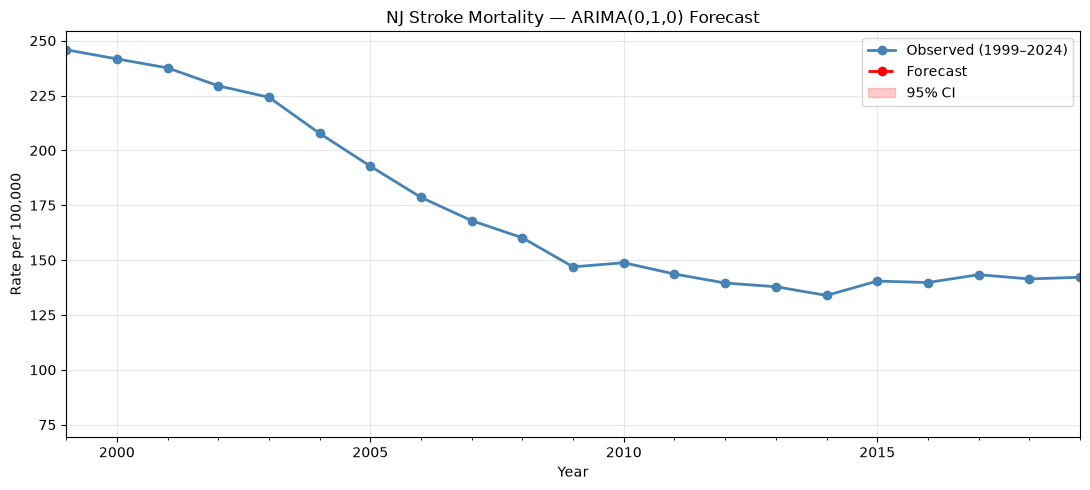

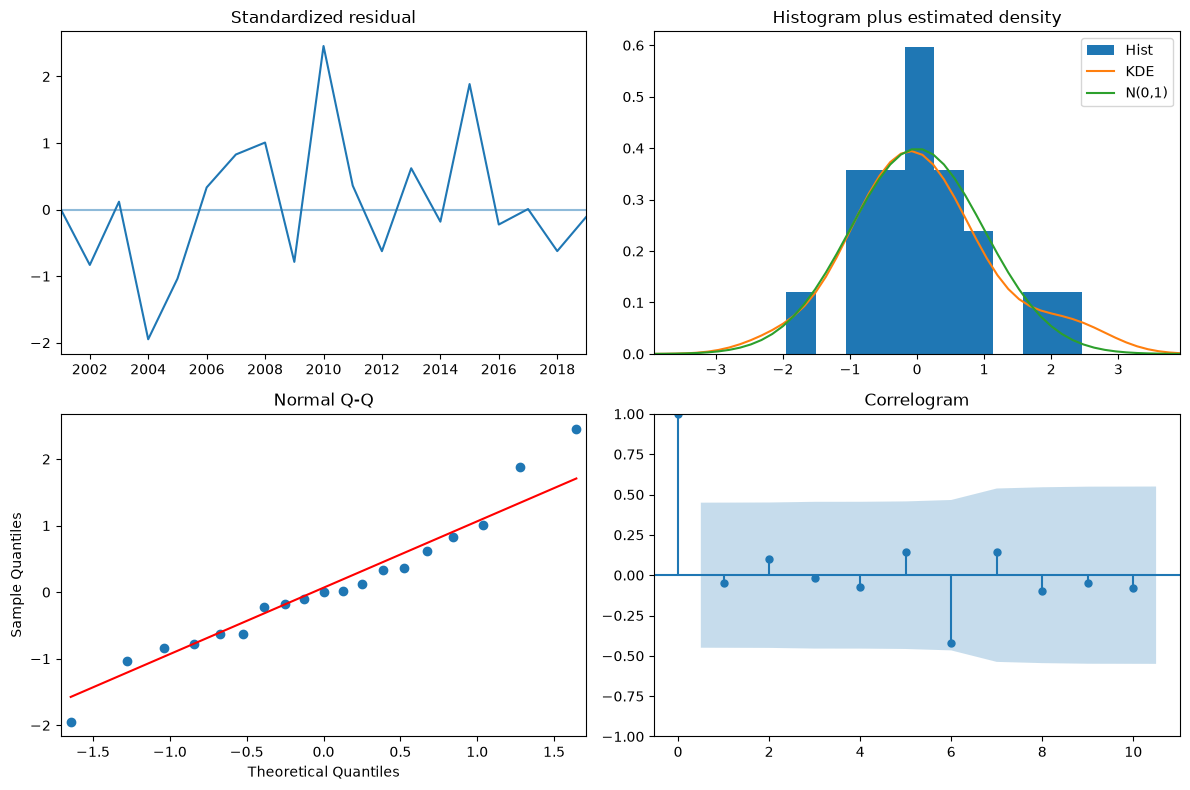


Ljung-Box (want p > 0.05):
     lb_stat  lb_pvalue
5   3.912801   0.562038
10  4.006410   0.947057


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pmdarima import auto_arima
from statsmodels.stats.diagnostic import acorr_ljungbox

# Assume nj_state is built (1999–2019, annual)

# --- Fit (already done) ---
model = auto_arima(nj_state, seasonal=False, d=None,
                   start_p=0, max_p=2, start_q=0, max_q=2,
                   stepwise=True, trace=False,
                   information_criterion='aicc',
                   suppress_warnings=True)

# --- Forecast 2020–2025 ---
forecast, ci = model.predict(n_periods=6, return_conf_int=True)
future = pd.date_range(nj_state.index[-1] + pd.DateOffset(years=1),
                       periods=6, freq='YS')

out = pd.DataFrame({
    'forecast': forecast.round(2),
    'lower_95': ci[:, 0].round(2),
    'upper_95': ci[:, 1].round(2)
}, index=future)
print(out)

# --- Plot ---
fig, ax = plt.subplots(figsize=(11, 5))
nj_state.plot(ax=ax, marker='o', color='steelblue',
              linewidth=2, label='Observed (1999–2024)')
ax.plot(future, forecast, 'r--o', linewidth=2, label='Forecast')
ax.fill_between(future, ci[:, 0], ci[:, 1],
                color='red', alpha=0.2, label='95% CI')
ax.set_title('NJ Stroke Mortality — ARIMA(0,1,0) Forecast')
ax.set_xlabel('Year')
ax.set_ylabel('Rate per 100,000')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# --- Diagnostics ---
model.plot_diagnostics(figsize=(12, 8))
plt.tight_layout()
plt.show()

print("\nLjung-Box (want p > 0.05):")
print(acorr_ljungbox(model.resid(), lags=[5, 10], return_df=True))